In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import geopy
import plotly.express as px
import ast
import json
from pd_replicator import replicator
from datetime import datetime
import gc
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('mode.use_inf_as_na', True)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")
sns.set(rc={'figure.figsize':(10,6)})

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_40224/3665024186.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


# 1. Data Engineering

In [1]:
import pandas as pd

# Load data
df = pd.read_csv("../data/q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Mon, 6=Sun

# Month-end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Preview
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# 2. Temporal Train-Test Split

In [2]:
# Sort by date (VERY IMPORTANT)
df = df.sort_values('transaction_date')

# Define split index (80%)
split_index = int(len(df) * 0.8)

# Split data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Separate features and target
X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']

**Temporal Train-Test Split:**

The dataset was first sorted by transaction_date to ensure chronological order.

A temporal split was used, where the first 80% of the data (earlier records) was used for training, and the most recent 20% was used for testing.

A random split is inappropriate for time-ordered data because it can lead to data leakage, where the model is trained on future information and evaluated on past data. This results in overly optimistic performance and does not reflect real-world forecasting scenarios.

Using a temporal split ensures that the model is trained on past data and evaluated on future data, which better simulates real-world conditions.

# 3. Preprocessing Pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [
    'year', 'month', 'day_of_week', 'is_month_end',
    'store_id', 'is_weekend', 'is_festival',
    'competition_density'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [5]:
from sklearn.pipeline import Pipeline

In [6]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [7]:
pipeline.fit(X_train)
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

**Preprocessing Pipeline:**

A preprocessing pipeline was constructed using ColumnTransformer to handle different types of features.

Categorical variables (promotion_type, location_type, and store_size) were transformed using one-hot encoding to convert them into numerical format. Numerical features were scaled using StandardScaler to ensure that all features are on a comparable scale.

The pipeline was fit only on the training data and then applied to both training and test sets to prevent data leakage and ensure a fair evaluation of model performance.

# 4. Model Training & Evaluation

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [9]:
#Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [10]:
#Random Forest Pipelineabs
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [11]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

**Evaluation**

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
#Linear Regression 

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890644
Linear Regression MAE: 21.05292667458842


In [16]:
#Random Forest

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.722854103942158
Random Forest MAE: 24.95041666666667


In [28]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

**Parity plot**

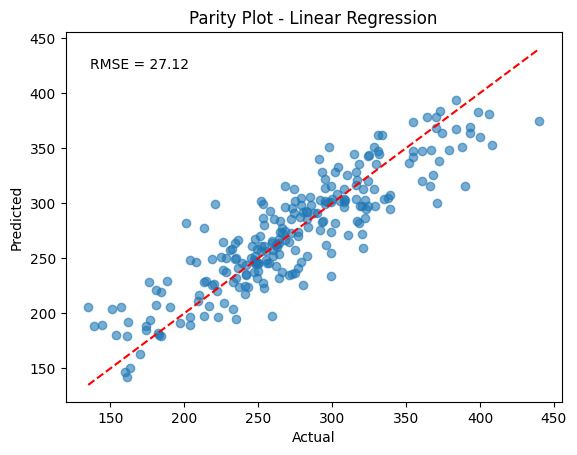

In [29]:
#linear regression
plt.figure()
plt.scatter(y_test, y_pred_lr, alpha=0.6)

# Diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.title("Parity Plot - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# ✅ Add RMSE here
plt.text(0.05, 0.9, f"RMSE = {rmse_lr:.2f}", transform=plt.gca().transAxes)

plt.show()

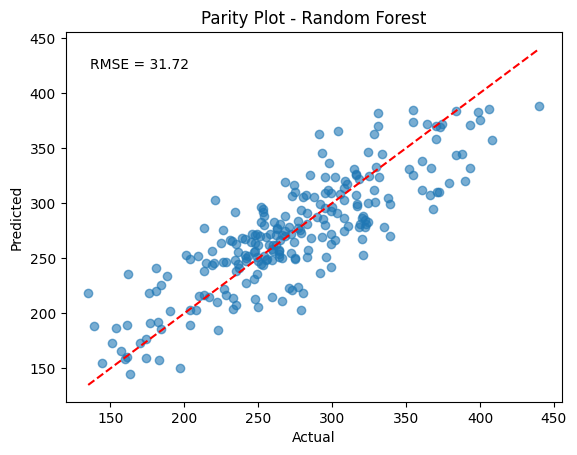

In [30]:
#Random forest
plt.figure()
plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.title("Parity Plot - Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# ✅ Add Rmse here
plt.text(0.05, 0.9, f"RMSE = {rmse_rf:.2f}", transform=plt.gca().transAxes)

plt.show()

**Feature Importance**

In [22]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5
feature_importance_df.head(5)

,feature,importance
7,cat__store_size_small,0.183954
14,num__is_festival,0.174489
5,cat__location_type_urban,0.140498
10,num__day_of_week,0.095432
12,num__store_id,0.062246


**Model Evaluation:**

Both Linear Regression and Random Forest models were evaluated using RMSE and MAE on the test set.

Linear Regression outperforms Random Forest, achieving a lower RMSE (27.12 vs 31.72) and lower MAE (21.05 vs 24.95). This indicates that Linear Regression produces more accurate predictions and smaller average errors.

The parity plots support this result, with Linear Regression predictions more closely aligned to the diagonal reference line, while Random Forest shows greater dispersion.

These results suggest that the relationship between the features and items_sold is largely linear, allowing Linear Regression to model the data effectively. The additional complexity of Random Forest does not provide improvement and may lead to less stable predictions.

Feature importance from the Random Forest model still provides useful insights, showing that store characteristics (store_size_small, location_type_urban) and temporal factors (is_festival, day_of_week) are key drivers of sales.

Overall, Linear Regression is the preferred model for this dataset due to its better predictive performance and simplicity.